In [1]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import numpy as np
from Pumps.Lauda import LaudaPumpFit
import matplotlib.pyplot as plt
from scipy.optimize import newton
import Experiments.NaturalConvection as nc
import ht 

8.26


Definimos serpentin

In [2]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=0.787687, orientation=-90, material="copper", vueltas = 5, pitch=12e-3)

Definimos el sistema

In [3]:
fluxsys = PipingSystem()
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(1.05+1.7)) 
fluxsys.add_coil(coil) # Serpentin
fluxsys.add_singularity_loss(SingularityLoss(1.7)) 
fluxsys.add_tube(Tube(d_in = 5.15e-3, d_out = 6.35e-3, lenght=0.1, orientation=0, material="copper")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(0.5)) 
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
fluxsys.conect() # Conectar

Definimos el Fluido

In [4]:
tl = 273.15 + 5
pl = 101325        
mul = 0.0026 # Pa*s
rhol = 988.4 # kg/m3
cpl = 4300 # J /(kg K)
kl = 0.51 # W/(m K)
prl = mul*cpl/kl


print(prl, kl)

21.92156862745098 0.51


In [ ]:
# # Condiciones base
# tl = 273.15 + 5  # Temperatura en Kelvin (5 °C)
# pl = 101325      # Presión en Pascales (1 atm)
# fluido = "Water" # Nombre del fluido en CoolProp

# # --- Propiedades termofísicas evaluadas con CoolProp ---

# # Viscosidad dinámica (Pa*s) -> Clave: 'V'
# mul = cp.PropsSI('V', 'T', tl, 'P', pl, fluido)

# # Densidad (kg/m^3) -> Clave: 'D'
# rhol = cp.PropsSI('D', 'T', tl, 'P', pl, fluido)

# # Calor específico a presión constante (J/(kg*K)) -> Clave: 'C' o 'Cmass'
# cpl = cp.PropsSI('C', 'T', tl, 'P', pl, fluido)

# # Conductividad térmica (W/(m*K)) -> Clave: 'L'
# kl = cp.PropsSI('L', 'T', tl, 'P', pl, fluido)

# # Número de Prandtl (adimensional) -> Clave: 'Prandtl'
# # (También puedes mantener tu fórmula original: prl = mul * cpl / kl)
# prl = cp.PropsSI('Prandtl', 'T', tl, 'P', pl, fluido)


# # Opcional: Imprimir para verificar los valores reales a 5°C
# print(f"Viscosidad (mul): {mul:.6f} Pa*s")
# print(f"Densidad (rhol): {rhol:.2f} kg/m3")
# print(f"Calor Específico (cpl): {cpl:.2f} J/(kg K)")
# print(f"Conductividad (kl): {kl:.4f} W/(m K)")
# print(f"Prandtl (prl): {prl:.2f}")

Viscosidad (mul): 0.001518 Pa*s
Densidad (rhol): 999.97 kg/m3
Calor Específico (cpl): 4205.04 J/(kg K)
Conductividad (kl): 0.5678 W/(m K)
Prandtl (prl): 11.24


Buscamos donde cruza la curva del sistema con la curva de la bomba

In [5]:
Q_op, Q_op_lmin, dp_op, dh_op = fluxsys.cross_system_pump(rhol,mul, LaudaPumpFit.Pa4m3s, 3.25e-5,verbose=True);


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    1.791 L/min
 Caudal volumétrico      : 2.98e-05 m³/s
 Presión de cruce   :  18105.2 Pa
 Pérdida de altura  :    1.867 m.c.a.
═════════════════════════════════════════════



In [33]:
for el in fluxsys.system:
    if isinstance(el, Tube):
        print(type(el), el.regime, el.perdida_alt*rhol*9.81, el.u, el.re)

<class 'Elements.Tube.Tube'> laminar 182.33953009182264 0.23565338788870252 1137.7236804164456
<class 'Elements.Coil.Coil'> laminar 11847.328456286834 1.4330675815842708 2805.648687628904
<class 'Elements.Tube.Tube'> turbulent 878.8791907773042 1.4330675815842708 2805.648687628904
<class 'Elements.Tube.Tube'> laminar 182.33953009182264 0.23565338788870252 1137.7236804164456


In [25]:
fluxsys.system[0].friction_factor

np.float64(0.056252674618299074)

In [28]:
fluxsys.system[-3].friction_factor

np.float64(0.04459645384564763)

In [43]:
caudales = np.arange(0.1, 10, 0.2)/60/1000
bomba = LaudaPumpFit.Pa4m3s(caudales)
sistema = []
for i in caudales:
    _ , pa = fluxsys.get_perdida_altura_closed(i, rhol, mul)
    sistema.append(pa)
sistema = np.array(sistema)

In [65]:
max(caudales)*60*1000

np.float64(9.9)

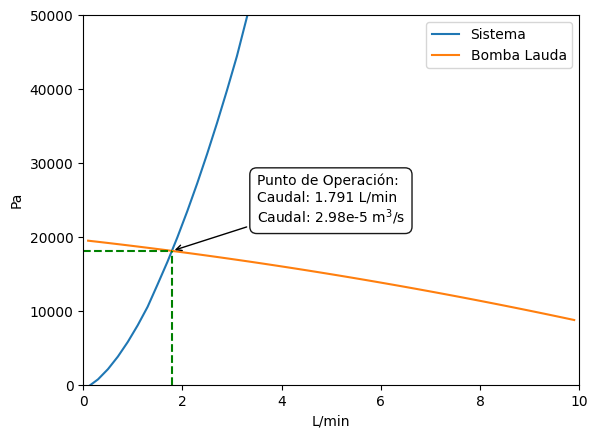

In [68]:
plt.figure()
plt.plot(caudales * 60 * 1000, sistema, label="Sistema")
plt.plot(caudales * 60 * 1000, bomba, label="Bomba Lauda")
plt.ylabel("Pa")
plt.ylim(0, 50000)
plt.xlabel("L/min")
plt.xlim(0, 10)

# Líneas discontinuas del punto de operación
plt.axvline(1.791, ymax=18105/50000, color="green", linestyle="--")
plt.axhline(18105, xmax=1.791/10.0, color="green", linestyle="--")

# Cuadro de texto indicando el caudal en ambas unidades
texto_anotacion = (
    "Punto de Operación:\n"
    "Caudal: 1.791 L/min\n"
    "Caudal: 2.98e-5 m$^3$/s"
)

plt.annotate(
    texto_anotacion,
    xy=(1.791, 18105),          # Coordenadas a las que apunta la flecha
    xytext=(3.5, 22000),        # Coordenadas donde se ubica el cuadro de texto
    arrowprops=dict(arrowstyle="->", color="black"),
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9)
)

plt.legend()
plt.show()

In [ ]:
def ap_from_T(T):
    return (2.5179e-7) * (T**2) + (-1.3127e-4) * T + (1.7210e-2)
def nu_from_T(T):
    return  1.3686547347844438e-06*np.exp(1913.7989961446747/T)

In [ ]:
m_dot = Q_op*rhol
# coil = TuClaseSerpentin(...)
# cpl, kl, mul, prl, rhol = ... (Propiedades del fluido interno)
def calcular_salida_y_pared(twater, tin, twall_guess=283.15, gas = False):
    """
    Simulador predictivo real usando el método epsilon-NTU global.
    Garantiza que el calor transferido sea idéntico al cambio de entalpía del fluido.
    """
    tol = 0.05
    relax = 0.2  # Un poco más alto para acelerar, ya que el método es más estable
    max_iter = 5000
    
    twall_out = twall_guess 
    tout = tin + 1.0 
    q = 0
    
    for i in range(max_iter):
        
        # --- 1) LADO INTERNO (Fluido) ---
        Re = (4 * m_dot) / (np.pi * coil.d_in * mul)
        coil.set_hidraulica(Q_op, rhol, mul)
        hi = coil.get_ht(prl, prl, mul, mul, kl)
        
        R_int = 1 / (hi * coil.area_in)
        
        # --- 2) PARED (Conducción) ---
        R_cond = np.log(coil.d_out / coil.d_in) / (2 * np.pi * coil.conductivity * coil.lenght)
        
        # --- 3) LADO EXTERNO (Baño y Rayleigh) ---
        tfo = (twater + twall_out) / 2
        if np.isnan(tfo) or tfo < 273.16: tfo = 273.20
            
        beta = cp.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', tfo, 'P', 101325, "water") if not gas else ap_from_T(tfo)
        prandtl = (
                cp.PropsSI('Prandtl', 'T', tfo, 'P', 101325, "water") 
                if not gas 
                else nu_from_T(tfo) * cp.PropsSI('Cp', 'T', tfo, 'P', 101325, "water") / cp.PropsSI('conductivity', 'T', tfo, 'P', 101325, "water")
                )
        nu_o = cp.PropsSI('V', 'T', tfo, 'P', 101325, "water") / cp.PropsSI('D', 'T', tfo, 'P', 101325, "water") if not gas else nu_from_T(tfo)
        k_bath = cp.PropsSI('conductivity', 'T', tfo, 'P', 101325, "water")
        
        delta_T = abs(twater - twall_out)
        if delta_T < 0.01: delta_T = 0.01
            
        gr = (9.81 * beta * delta_T * (coil.d_out**3)) / (nu_o**2)
        
        Nuo = ht.conv_free_immersed.Nu_coil_Xin_Ebadian(Pr=prandtl, Gr=gr, horizontal=True)
        ho = (Nuo * k_bath) / coil.d_out
        
        R_ext = 1 / (ho * coil.area_out)
        
        # --- 4) BALANCE TÉRMICO GLOBAL (MÉTODO EPSILON-NTU) ---
        # 1/UA es la suma de las resistencias reales de la serie térmica
        UA = 1 / (R_int + R_cond + R_ext)
        
        # C_min en este caso es simplemente el fluido interno (el baño exterior es infinito/estancado)
        C_min = m_dot * cpl
        
        NTU = UA / C_min
        epsilon = 1 - np.exp(-NTU)  # Perfil para fluido con temperatura externa constante (banco/tanque)
        
        # Calor máximo posible vs Calor real
        q_max = C_min * (twater - tin)
        q_new = epsilon * q_max
        
        # --- 5) RECALCULAR TEMPERATURAS (Consistentes) ---
        # La temperatura de pared externa depende estrictamente del calor que logra salir al baño
        twall_out_new = twater - q_new * R_ext
        
        # La temperatura de salida es consecuencia directa de la energía ganada
        tout_new = tin + q_new / C_min
        
        # --- 6) CONVERGENCIA ---
        if abs(twall_out_new - twall_out) < tol:
            twall_out = twall_out_new
            tout = tout_new
            q = q_new
            break
            
        # Aplicamos relajación sobre la temperatura de la pared para el cálculo de propiedades del fluido exterior
        twall_out = twall_out + relax * (twall_out_new - twall_out)
        
    return tout, twall_out, q


In [7]:
# --- SIMULACIÓN TRANSITORIA (20 MINUTOS) ---

M_tanque = 0.350*0.9985 # Masa de agua en el baño (kg)
Cp_tanque = 4180  # J/kgC (Calor específico del agua)
dt = 0.5          # Paso de tiempo en segundos
tiempo_total = 6*60 # 20 minutos en segundos

# Condiciones iniciales de la simulación
t_bath_actual = 273.15+16 # Temperatura inicial del baño (Ej: 20°C en Kelvin)
tin = 273.15+5         # Temperatura de entrada al serpentín (Ej: 80°C en Kelvin)

# Listas para guardar el historial y graficar después
historial_tiempo = []
historial_t_bath = []
historial_tout = []
historial_q = []
historial_twall = []

print("Iniciando simulación de 20 minutos...")

for t in np.arange(0, tiempo_total, dt):
    # 'tin' se mantiene constante a 273.15 + 8 (o lo que dictes)
    if t == 0:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin)
    else:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin, twall_guess=twall_out)
    
    # 2. Guardar datos actuales en el historial
    historial_tiempo.append(t) # Guardar en minutos
    historial_t_bath.append(t_bath_actual - 273.15) # Guardar en Celsius para fácil lectura
    historial_tout.append(tout - 273.15)
    historial_q.append(q)
    historial_twall.append(twall_out - 273.15)
    
    
    # 3. Calcular el cambio de temperatura del baño
    dT_bath = (-q * dt) / (M_tanque * cp.PropsSI('C', 'T', t_bath_actual, 'P', 101325, "water"))
    
    # 4. Actualizar temperatura para el siguiente segundo
    t_bath_actual += dT_bath

print("Simulación finalizada.")

Iniciando simulación de 20 minutos...
Simulación finalizada.


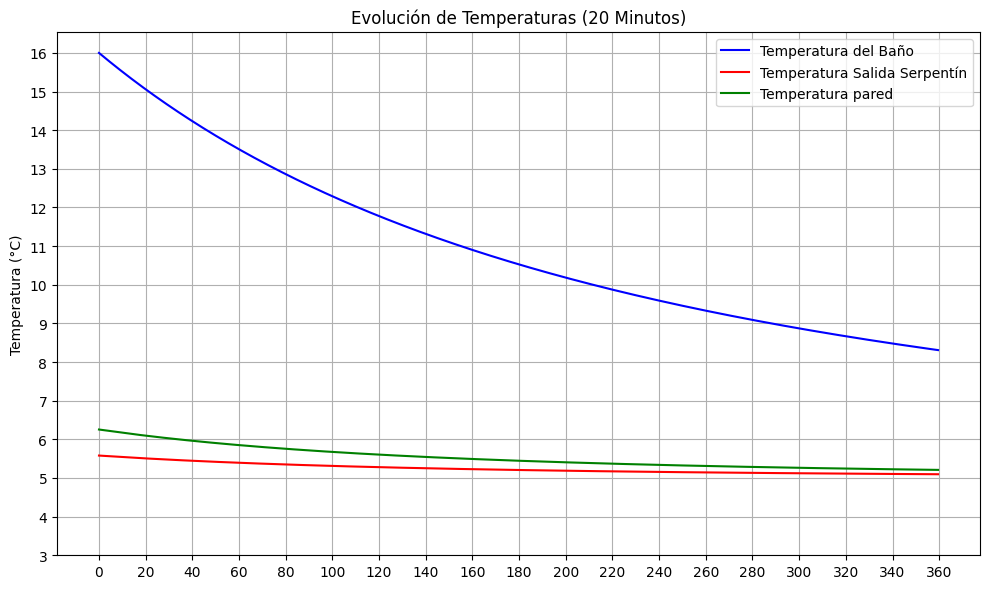

In [8]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 1, 1)
plt.plot(historial_tiempo, historial_t_bath, label="Temperatura del Baño", color='blue')
plt.plot(historial_tiempo, historial_tout, label="Temperatura Salida Serpentín", color='red')
plt.plot(historial_tiempo, historial_twall, label ="Temperatura pared", color = "green")
plt.yticks([i for i in np.arange(3,17,1)])
plt.xticks([i for i in np.arange(0,370,20)])
plt.title("Evolución de Temperaturas (20 Minutos)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)

# plt.subplot(2, 1, 2)
# plt.plot(historial_tiempo, historial_q, label="Calor Transferido (q)", color='orange')
# plt.xlabel("Tiempo (Minutos)")
# plt.ylabel("Calor (W)")
# plt.legend()
# plt.grid(True)

plt.tight_layout()
plt.show()